# DiffusionSat feature similarity exploration

Three cosine-similarity experiments on the same `N_SAMPLES` satellite chunks from flight `03`:

1. **Sat-inference vs. Sat-augmented** — same chunk through `inference_sat_transforms` vs. `train_sat_uav_sim_transforms`. Measures how much the backbone cares about the simulated domain-gap augmentation.
2. **UAV vs. Sat-inference** — real UAV image vs. its GPS-matched satellite chunk through `inference_sat_transforms`. Measures the true query–gallery domain gap.
3. **UAV vs. Sat-augmented** — same UAV image vs. the same chunk through `train_sat_uav_sim_transforms`. Checks whether UAV-sim augmentation moves satellite embeddings *closer to* or *further from* UAV embeddings.

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import warnings
from pathlib import Path

import torch

warnings.filterwarnings("ignore", message=".*invalid escape sequence.*")
warnings.filterwarnings("ignore", message=".*pkg_resources is deprecated as an API.*")
warnings.filterwarnings("ignore", message=".*Importing from cross_attention is deprecated.*")
warnings.filterwarnings("ignore", message=".*Some weights of the model checkpoint.*")

VISLOC_ROOT = Path(os.environ["VISLOC_ROOT"])
DIFFUSIONSAT_256_CHCKPT = Path(os.environ["DIFFUSIONSAT_256_CHCKPT"])

FLIGHT_ID = "03"
N_SAMPLES = 64  # number of UAV images (and their matched satellite chunks) to use
RANDOM_SEED = 42
DEVICE = torch.device("cuda")
NUM_WORKERS = 4

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
from src.backbone import DiffusionSatBackbone
from src.ldm_extractor import LDMExtractorCfg

torch.set_float32_matmul_precision("high")

backbone = DiffusionSatBackbone(DIFFUSIONSAT_256_CHCKPT, DEVICE, dtype=torch.bfloat16)

ldm_cfg = LDMExtractorCfg(
  batch_size=32,
  save_timesteps=[48, 46, 42],
  num_timesteps=50,
  layer_idxs={"down_blocks": {"attn1": "all"}},
)
backbone.set_ldm_extractor_cfg(ldm_cfg)

Some weights of the model checkpoint at /workspace/checkpoints/finetune_sd21_256_sn-satlas-fmow_snr5_md7norm_bs64_trimmed were not used when initializing SatUNet: ['metadata_embedding.1.linear_2.bias', 'metadata_embedding.1.linear_2.weight', 'metadata_embedding.5.linear_1.weight', 'metadata_embedding.6.linear_2.bias', 'metadata_embedding.0.linear_1.weight', 'metadata_embedding.4.linear_2.weight', 'metadata_embedding.5.linear_2.weight', 'metadata_embedding.1.linear_1.bias', 'metadata_embedding.0.linear_2.bias', 'metadata_embedding.2.linear_1.weight', 'metadata_embedding.1.linear_1.weight', 'metadata_embedding.3.linear_2.bias', 'metadata_embedding.6.linear_1.bias', 'metadata_embedding.3.linear_1.bias', 'metadata_embedding.2.linear_1.bias', 'metadata_embedding.0.linear_1.bias', 'metadata_embedding.3.linear_1.weight', 'metadata_embedding.6.linear_1.weight', 'metadata_embedding.2.linear_2.weight', 'metadata_embedding.3.linear_2.weight', 'metadata_embedding.4.linear_1.weight', 'metadata_embe

## Build GPS-matched UAV ↔ satellite pairs

For each UAV image, `build_ground_truth` finds all satellite chunks whose bounding box contains the UAV GPS coordinate. We take the first (closest-centre) match as the canonical paired chunk.

In [14]:
import numpy as np
from torch.utils.data import DataLoader, Subset

from src.datasets.visloc import (
  SatChunkDataset,
  UAVDataset,
  inference_sat_transforms,
  inference_uav_transforms,
  train_sat_uav_sim_transforms,
)
from src.evaluation import build_ground_truth

# Full satellite chunk dataset (no transform yet — we'll build subsets per transform).
sat_full_inference = SatChunkDataset(root=VISLOC_ROOT, flight_id=FLIGHT_ID, transform=inference_sat_transforms)
sat_full_augmented = SatChunkDataset(root=VISLOC_ROOT, flight_id=FLIGHT_ID, transform=train_sat_uav_sim_transforms)

# UAV dataset.
uav_full = UAVDataset(root=VISLOC_ROOT, flight_id=FLIGHT_ID, transform=inference_uav_transforms)

# GPS-based ground truth: for each UAV image → list of matching chunk indices.
uav_coords = np.array([(uav_full.records.iloc[i]["lat"], uav_full.records.iloc[i]["lon"]) for i in range(len(uav_full))])
ground_truth = build_ground_truth(uav_coords, sat_full_inference.chunk_bboxes)

# Randomly sample N_SAMPLES UAV images; for each, take the closest-centre matched chunk.
valid_uav_indices = [i for i, gt in enumerate(ground_truth) if len(gt) > 0]
rng = np.random.default_rng(RANDOM_SEED)
valid_uav_indices = rng.choice(valid_uav_indices, size=min(N_SAMPLES, len(valid_uav_indices)), replace=False).tolist()
matched_chunk_indices = [ground_truth[i][0] for i in valid_uav_indices]

print(f"UAV images used      : {len(valid_uav_indices)}")
print(f"Unique chunks matched: {len(set(matched_chunk_indices))}")

UAV images used      : 64
Unique chunks matched: 63


In [15]:
# Build datasets / loaders for all three views.
uav_subset       = Subset(uav_full,          valid_uav_indices)
sat_inf_subset   = Subset(sat_full_inference, matched_chunk_indices)
sat_aug_subset   = Subset(sat_full_augmented, matched_chunk_indices)

loader_uav     = DataLoader(uav_subset,     batch_size=ldm_cfg.batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
loader_sat_inf = DataLoader(sat_inf_subset, batch_size=ldm_cfg.batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
loader_sat_aug = DataLoader(sat_aug_subset, batch_size=ldm_cfg.batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

## Extract embeddings

In [16]:
from tqdm import tqdm

from src.embedders import PoolConcatEmbedder, normalize_embeddings


def extract_embeddings(loader, backbone, embedder, device):
  all_embs = []
  for imgs, *_ in tqdm(loader):
    imgs = imgs.to(device, dtype=torch.bfloat16)
    feats = backbone(imgs)
    embs = embedder(feats)
    all_embs.append(embs.float().cpu())
  return normalize_embeddings(torch.cat(all_embs, dim=0))


# Probe feature dims from a single forward pass.
with torch.no_grad():
  _probe_imgs, *_ = next(iter(loader_sat_inf))
  _probe_feats = backbone(_probe_imgs.to(DEVICE, dtype=torch.bfloat16))

feature_dims = {ts: [f.shape[1] for f in feats] for ts, feats in _probe_feats.items()}
embedder = PoolConcatEmbedder(feature_dims=feature_dims, save_timesteps=ldm_cfg.save_timesteps)
print(f"Embedding dim: {embedder.embedding_dim}")

Embedding dim: 40320


In [17]:
print("Extracting UAV embeddings...")
embs_uav     = extract_embeddings(loader_uav,     backbone, embedder, DEVICE)

print("Extracting satellite (inference) embeddings...")
embs_sat_inf = extract_embeddings(loader_sat_inf, backbone, embedder, DEVICE)

print("Extracting satellite (UAV-sim augmented) embeddings...")
embs_sat_aug = extract_embeddings(loader_sat_aug, backbone, embedder, DEVICE)

print(f"\nAll shapes: {embs_uav.shape}")

Extracting UAV embeddings...


100%|██████████| 2/2 [00:12<00:00,  6.04s/it]


Extracting satellite (inference) embeddings...


100%|██████████| 2/2 [00:08<00:00,  4.44s/it]


Extracting satellite (UAV-sim augmented) embeddings...


100%|██████████| 2/2 [00:08<00:00,  4.45s/it]



All shapes: torch.Size([64, 13440])


## Experiment 1 — Sat-inference vs. Sat-augmented

Baseline: does augmentation (the UAV-simulation pipeline) significantly perturb satellite embeddings?

In [18]:
import matplotlib.pyplot as plt


def summarise(label, cos_sim):
  print(f"--- {label} ---")
  print(f"  mean={cos_sim.mean():.4f}  std={cos_sim.std():.4f}  min={cos_sim.min():.4f}  max={cos_sim.max():.4f}")
  print(f"  >0.9: {(cos_sim > 0.9).mean():.1%}  >0.8: {(cos_sim > 0.8).mean():.1%}  >0.5: {(cos_sim > 0.5).mean():.1%}")


def cross_retrieval(query_embs, gallery_embs, label):
  sim = query_embs @ gallery_embs.T  # (N, N)
  ranks = (sim > sim.diag().unsqueeze(1)).sum(dim=1).numpy()
  print(f"  {label}  R@1={( ranks<1).mean():.3f}  R@5={(ranks<5).mean():.3f}  R@10={(ranks<10).mean():.3f}")
  return sim


cos_inf_aug = (embs_sat_inf * embs_sat_aug).sum(dim=1).numpy()
summarise("Sat-inference vs. Sat-augmented", cos_inf_aug)

--- Sat-inference vs. Sat-augmented ---
  mean=0.9271  std=0.0295  min=0.8561  max=0.9741
  >0.9: 75.0%  >0.8: 100.0%  >0.5: 100.0%


In [19]:
cos_uav_inf = (embs_uav * embs_sat_inf).sum(dim=1).numpy()
cos_uav_aug = (embs_uav * embs_sat_aug).sum(dim=1).numpy()

summarise("UAV vs. Sat-inference", cos_uav_inf)
summarise("UAV vs. Sat-augmented", cos_uav_aug)

--- UAV vs. Sat-inference ---
  mean=0.8711  std=0.0271  min=0.7976  max=0.9210
  >0.9: 15.6%  >0.8: 98.4%  >0.5: 100.0%
--- UAV vs. Sat-augmented ---
  mean=0.8826  std=0.0307  min=0.7953  max=0.9332
  >0.9: 28.1%  >0.8: 98.4%  >0.5: 100.0%


## Per-sample similarity distributions — all three comparisons

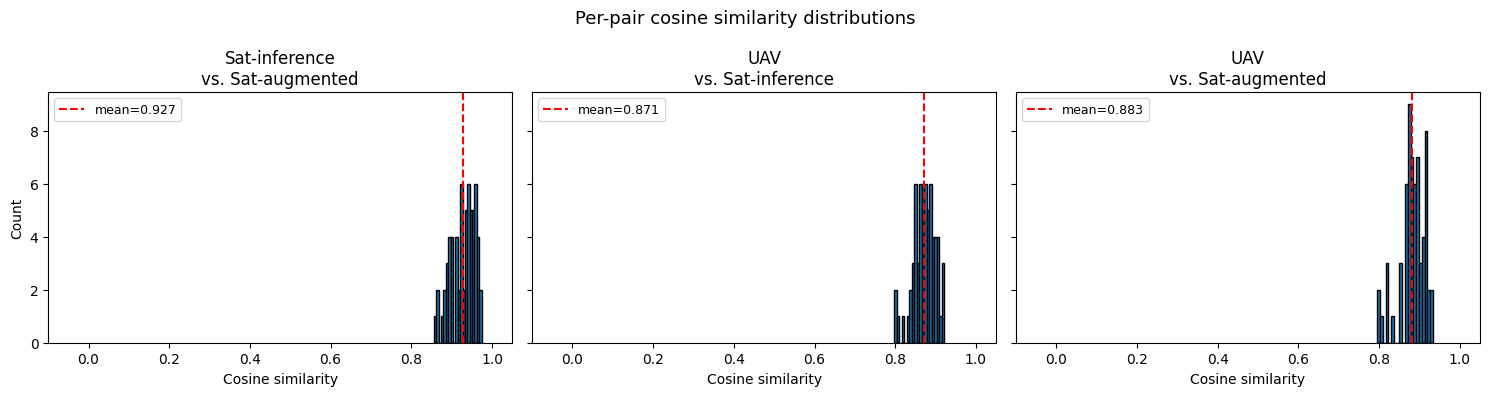

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

pairs = [
  (cos_inf_aug, "Sat-inference\nvs. Sat-augmented"),
  (cos_uav_inf, "UAV\nvs. Sat-inference"),
  (cos_uav_aug, "UAV\nvs. Sat-augmented"),
]

for ax, (sims, title) in zip(axes, pairs):
  ax.hist(sims, bins=20, edgecolor="black")
  ax.axvline(sims.mean(), color="red", linestyle="--", label=f"mean={sims.mean():.3f}")
  ax.set_xlim(-0.1, 1.05)
  ax.set_xlabel("Cosine similarity")
  ax.set_title(title)
  ax.legend(fontsize=9)

axes[0].set_ylabel("Count")
fig.suptitle("Per-pair cosine similarity distributions", fontsize=13)
plt.tight_layout()
plt.show()

## Pairwise similarity matrices + cross-retrieval R@k

Each matrix is `(N, N)` with the diagonal being the correct (matched-pair) similarity. High off-diagonal values mean many confusable chunks.

Cross-retrieval (correct match must be ranked first):
  Sat-inf queries → Sat-aug gallery  R@1=0.375  R@5=0.625  R@10=0.750
  UAV queries      → Sat-inf gallery  R@1=0.016  R@5=0.188  R@10=0.344
  UAV queries      → Sat-aug gallery  R@1=0.141  R@5=0.391  R@10=0.516


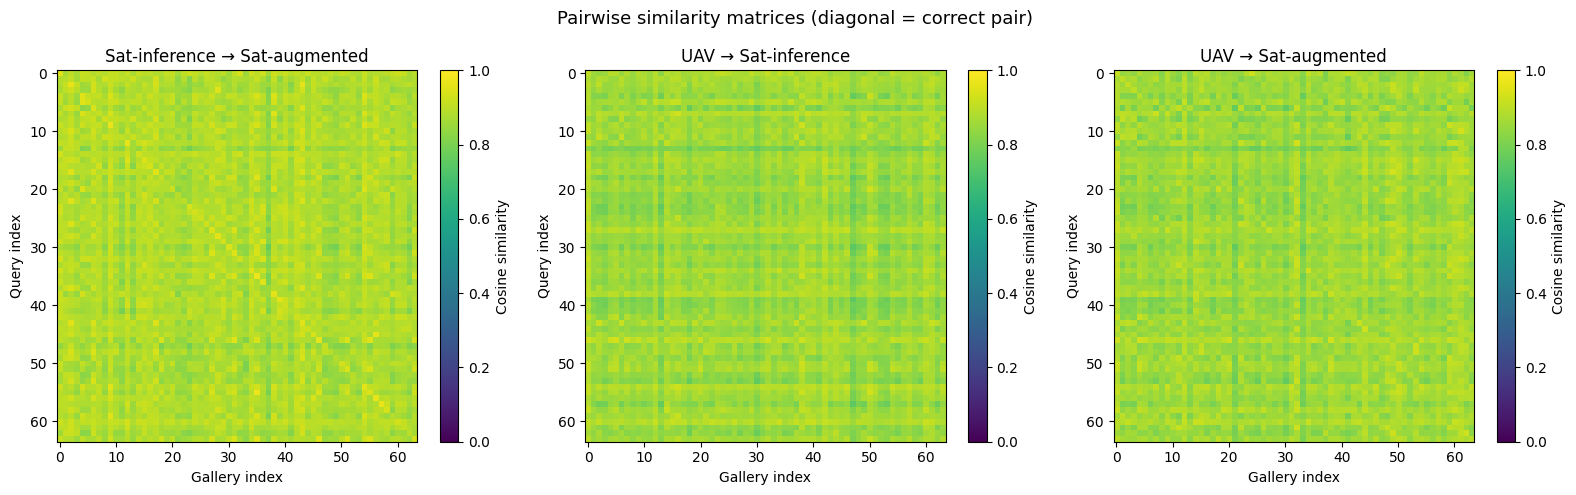

In [21]:
print("Cross-retrieval (correct match must be ranked first):")
sim_inf_aug = cross_retrieval(embs_sat_inf, embs_sat_aug, "Sat-inf queries → Sat-aug gallery")
sim_uav_inf = cross_retrieval(embs_uav,     embs_sat_inf, "UAV queries      → Sat-inf gallery")
sim_uav_aug = cross_retrieval(embs_uav,     embs_sat_aug, "UAV queries      → Sat-aug gallery")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

titles = [
  "Sat-inference → Sat-augmented",
  "UAV → Sat-inference",
  "UAV → Sat-augmented",
]
for ax, sim, title in zip(axes, [sim_inf_aug, sim_uav_inf, sim_uav_aug], titles):
  im = ax.imshow(sim.numpy(), vmin=0, vmax=1, cmap="viridis", aspect="auto")
  plt.colorbar(im, ax=ax, label="Cosine similarity")
  ax.set_title(title)
  ax.set_xlabel("Gallery index")
  ax.set_ylabel("Query index")

plt.suptitle("Pairwise similarity matrices (diagonal = correct pair)", fontsize=13)
plt.tight_layout()
plt.show()